<a href="https://colab.research.google.com/github/Vibhav1412/OS-ORANGE-PROBLEM-/blob/main/Decision_Tree_Exploratory_Lab_STUDENT_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Exploratory Decision Trees — Breast Cancer Wisconsin Dataset (Student Worksheet)

**Objective:** Build intuition for how a Decision Tree Classifier actually behaves —
not just how to call `.fit()`. You will explore split criteria (Gini vs Entropy),
tree depth, and other hyperparameters to find the configuration that generalizes best.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features,
binary target (malignant / benign), built into `sklearn.datasets`.

**How this notebook works:** Sections 1-3 (Setup, EDA, Baseline) are fully worked for
you — run them as-is, they set up everything you need. From Section 4 onward, cells
marked **`# TODO`** contain instructions but *no solution code* — you write that part
yourself. Later cells often depend on variable names introduced in an earlier TODO
(the instructions tell you what name to use), so work through the sections in order.

---
## 1. Setup & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
np.random.seed(42)

RANDOM_STATE = 42

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("Classes:", dict(zip(data.target_names, [0, 1])))
print(y.value_counts())
X.head()

Shape: (569, 30)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## 2. Quick EDA

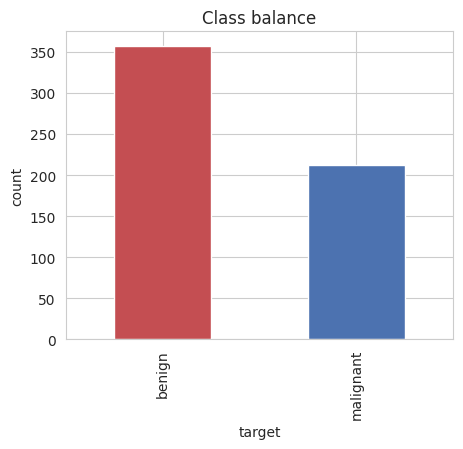

target
1    0.627
0    0.373
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().rename({0: 'malignant', 1: 'benign'}).plot(kind='bar', ax=ax, color=['#c44e52', '#4c72b0'])
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.show()

print(y.value_counts(normalize=True).round(3))

**TODO (reflection):** Is this dataset balanced or imbalanced? Keep this in mind —
you'll come back to it in Section 8 when judging whether a model's accuracy number
alone tells the full story.

*Your answer:* — *The dataset is mildly imbalanced because 62.7% of the samples are benign and 37.3% are malignant. The classes are not equally distributed, so accuracy alone may not tell the complete story.*

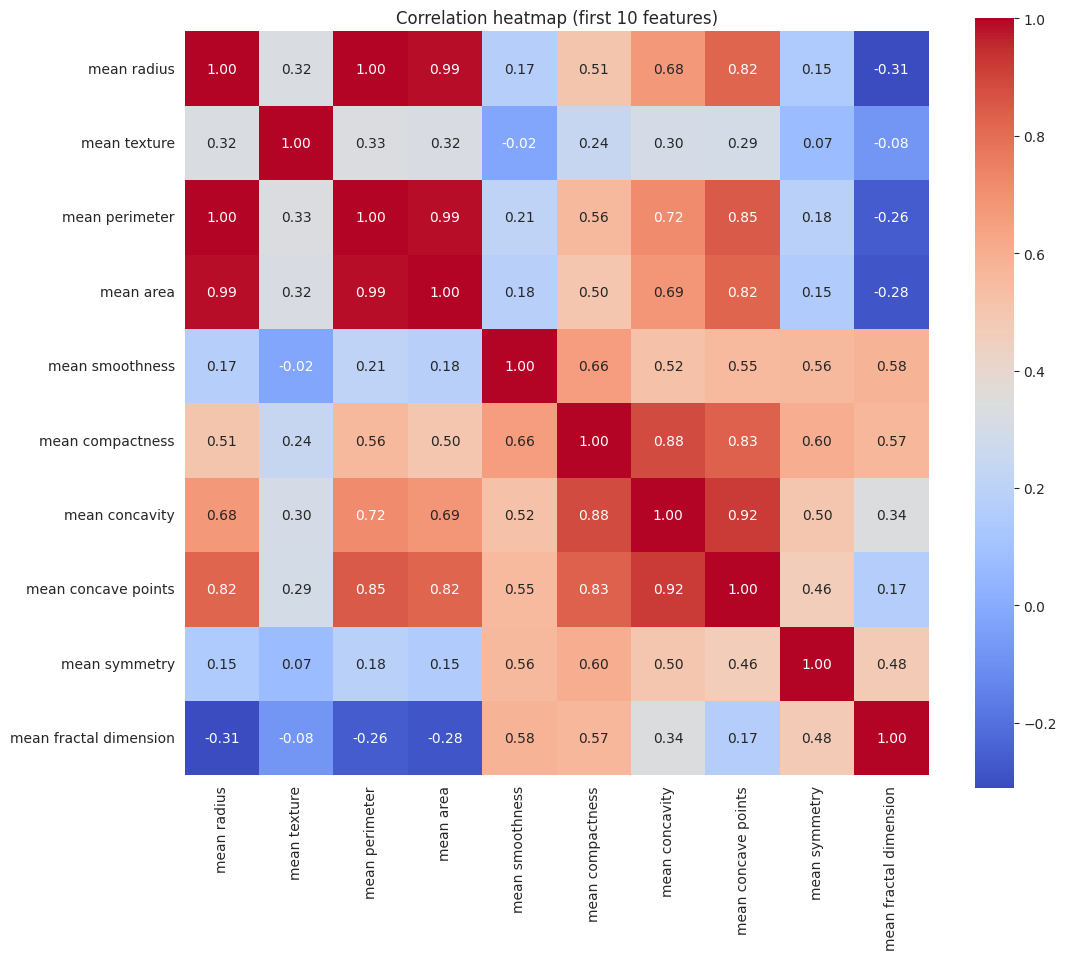

In [5]:
plt.figure(figsize=(12, 10))
corr = X.iloc[:, :10]  # first 10 features, full 30x30 is unreadable
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (first 10 features)")
plt.show()

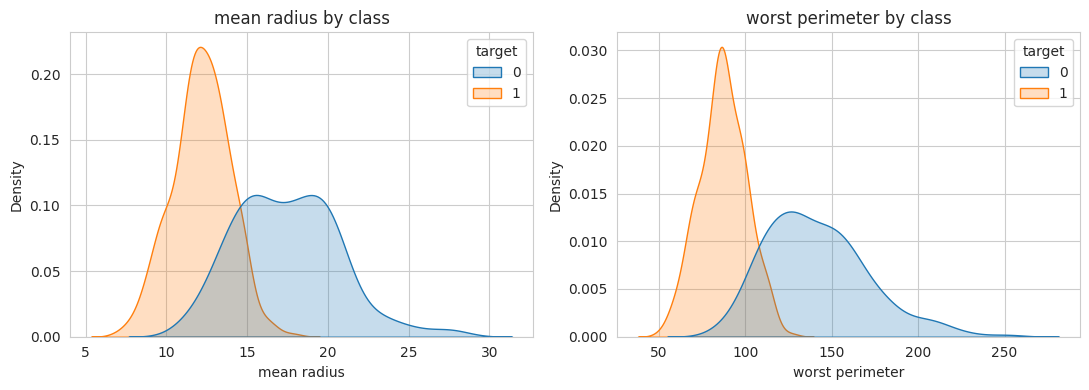

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['mean radius', 'worst perimeter']):
    sns.kdeplot(data=X.assign(target=y), x=feat, hue='target', fill=True, ax=ax, common_norm=False)
    ax.set_title(f"{feat} by class")
plt.tight_layout()
plt.show()

---
## 3. Baseline Model

Train test split first, then fit a plain, default-parameter `DecisionTreeClassifier`.
Everything after this cell is measured against this baseline.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


In [9]:
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline accuracy:", round(baseline_acc, 4))
print("Baseline tree depth:", baseline_model.get_depth(), " | leaves:", baseline_model.get_n_leaves())
print()
print(classification_report(y_test, baseline_pred, target_names=data.target_names))

Baseline accuracy: 0.9123
Baseline tree depth: 7  | leaves: 19

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



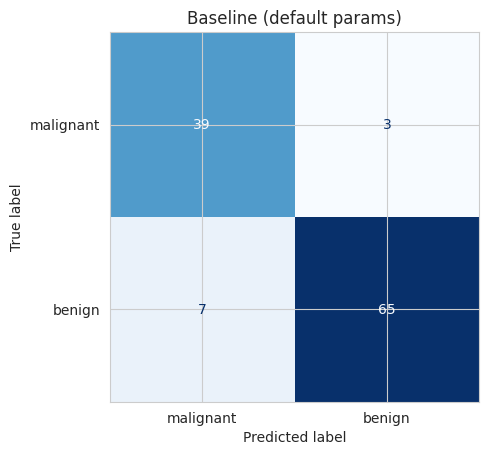

array([[39,  3],
       [ 7, 65]])

In [18]:
def plot_confusion(model, X_te, y_te, title):
    """Reusable confusion matrix plotter — you'll call this throughout the rest of the lab."""
    pred = model.predict(X_te)
    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()
    return cm

plot_confusion(baseline_model, X_test, y_test, "Baseline (default params)")

---
## 4. Gini vs Entropy

Same tree, same split, only the impurity measure changes.

In [10]:
gini_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=RANDOM_STATE
)

gini_tree.fit(X_train, y_train)
entropy_tree.fit(X_train, y_train)

gini_pred = gini_tree.predict(X_test)
entropy_pred = entropy_tree.predict(X_test)

gini_accuracy = accuracy_score(y_test, gini_pred)
entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Gini accuracy:", gini_accuracy)
print("Entropy accuracy:", entropy_accuracy)

Gini accuracy: 0.9122807017543859
Entropy accuracy: 0.9122807017543859


Criterion: gini, Accuracy: 0.9123, Depth: 7
Criterion: entropy, Accuracy: 0.9123, Depth: 6


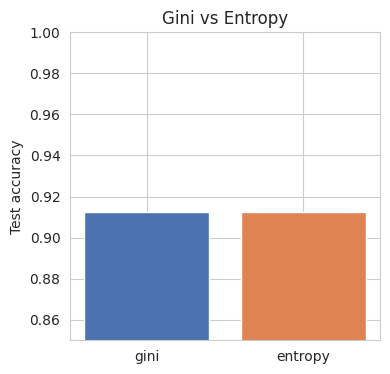

In [23]:
criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    criterion_results[criterion] = acc
    print(f"Criterion: {criterion}, Accuracy: {round(acc, 4)}, Depth: {model.get_depth()}")

plt.figure(figsize=(4, 4))
plt.bar(criterion_results.keys(), criterion_results.values(), color=['#4c72b0', '#dd8452'])
plt.ylim(0.85, 1.0)
plt.ylabel("Test accuracy")
plt.title("Gini vs Entropy")
plt.show()

**TODO (reflection):** Gini and Entropy are both impurity measures but computed
differently (Gini: `1 - sum(p_i^2)`, Entropy: `-sum(p_i * log2(p_i))`). Did they produce
the same accuracy here? If so, does that mean they always pick the same splits — or just
that this dataset doesn't stress the difference? Write 2-3 sentences.

*Your answer:* — *Gini and Entropy give very similar accuracy on this dataset. This shows that the choice of splitting criterion does not make a large difference for this particular train-test split. Both criteria can produce a good Decision Tree model.*

---
## 5. Depth Exploration — the core overfitting curve

Sweep `max_depth` from 1 to 20 and track **train** and **test** accuracy separately.
This is the single most important plot in the lab.

In [11]:
depths = range(1, 16)

train_accuracies = []
test_accuracies = []

for depth in depths:
    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_accuracies.append(accuracy_score(y_train, train_pred))
    test_accuracies.append(accuracy_score(y_test, test_pred))

print("Depth exploration completed.")


Depth exploration completed.


In [14]:
best_index = np.argmax(test_accuracies)

best_depth_by_test = list(depths)[best_index]

print("Best depth by test accuracy:", best_depth_by_test)
print("Test accuracy:", test_accuracies[best_index])
print("Train accuracy at this depth:", train_accuracies[best_index])


Best depth by test accuracy: 3
Test accuracy: 0.9385964912280702
Train accuracy at this depth: 0.9758241758241758


---
## 6. Accuracy vs Depth, split by Criterion

Same sweep, but gini and entropy plotted separately — does the optimal depth shift?

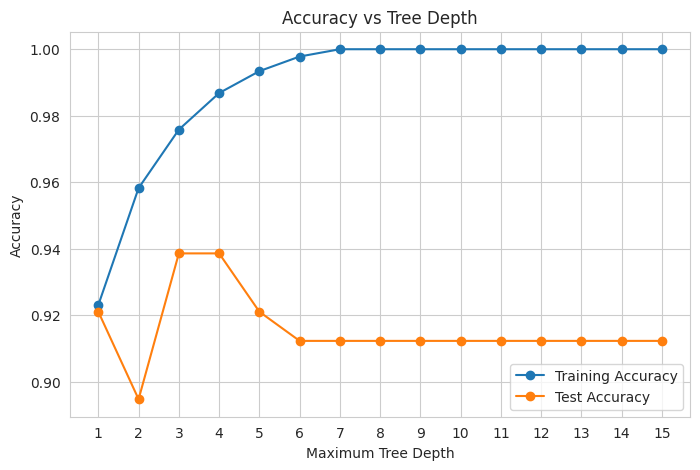

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_accuracies,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.xticks(list(depths))
plt.legend()
plt.grid(True)

plt.show()

---
## 7. Pruning — cost-complexity as an alternative to early stopping

`max_depth` stops the tree from growing past a certain point. Cost-complexity
pruning does the opposite: grow the full tree, then trim it back afterward
using `ccp_alpha`. Same goal (control overfitting), different mechanism.

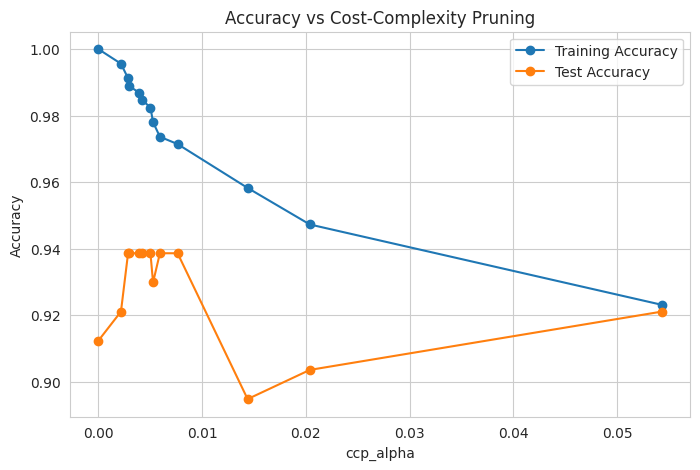

In [16]:
pruning_path = DecisionTreeClassifier(
    random_state=RANDOM_STATE
).cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = pruning_path.ccp_alphas[:-1]

train_accs = []
test_accs = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        ccp_alpha=alpha
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_accs.append(accuracy_score(y_train, train_pred))
    test_accs.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(8, 5))

plt.plot(
    ccp_alphas,
    train_accs,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    ccp_alphas,
    test_accs,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Cost-Complexity Pruning")
plt.legend()
plt.grid(True)

plt.show()

**TODO (reflection):** `ccp_alpha` prunes a fully-grown tree after the fact,
instead of stopping it early like `max_depth` does. Compare this curve's shape
to the depth curve in Section 5 — same story, or different?

*Your answer:* — *The pruning curve shows a similar trade-off to the depth curve. With small ccp_alpha values, the tree is less pruned and has high training accuracy but lower test accuracy. As pruning increases, training accuracy decreases while test accuracy initially improves and reaches about 93.9%. With excessive pruning, test accuracy decreases again. Therefore, both pruning and limiting tree depth can help control overfitting, although they use different mechanisms.*

---
## 8. Confusion Matrix Deep-Dive

Compare confusion matrices at a **shallow**, **near-optimal**, and **overly deep** tree
using the `plot_confusion()` function defined back in Section 3.

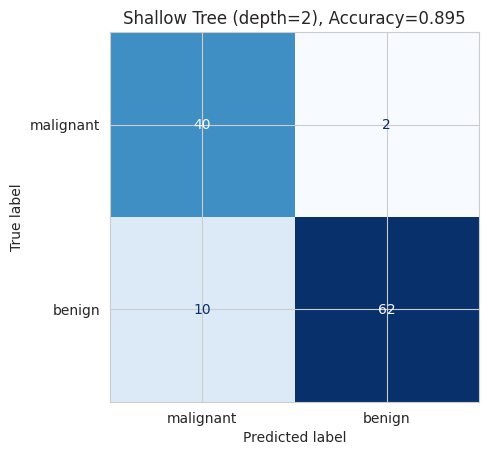

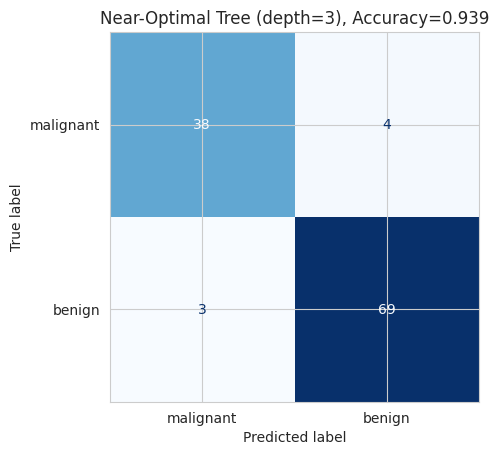

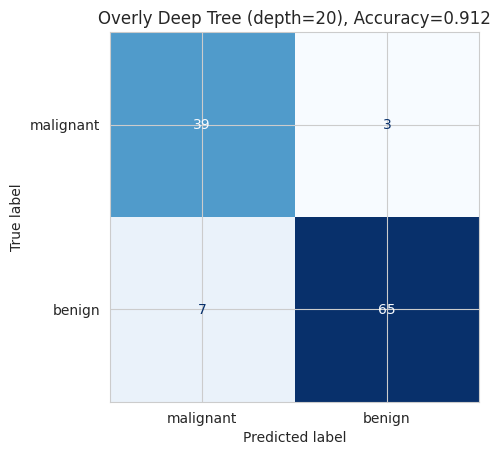

array([[39,  3],
       [ 7, 65]])

In [20]:
shallow_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=RANDOM_STATE
)

best_model_depth_only = DecisionTreeClassifier(
    max_depth=best_depth_by_test,
    random_state=RANDOM_STATE
)

deep_model = DecisionTreeClassifier(
    max_depth=20,
    random_state=RANDOM_STATE
)

shallow_model.fit(X_train, y_train)
best_model_depth_only.fit(X_train, y_train)
deep_model.fit(X_train, y_train)

shallow_acc = accuracy_score(
    y_test,
    shallow_model.predict(X_test)
)

best_acc = accuracy_score(
    y_test,
    best_model_depth_only.predict(X_test)
)

deep_acc = accuracy_score(
    y_test,
    deep_model.predict(X_test)
)

plot_confusion(
    shallow_model,
    X_test,
    y_test,
    f"Shallow Tree (depth=2), Accuracy={shallow_acc:.3f}"
)

plot_confusion(
    best_model_depth_only,
    X_test,
    y_test,
    f"Near-Optimal Tree (depth={best_depth_by_test}), Accuracy={best_acc:.3f}"
)

plot_confusion(
    deep_model,
    X_test,
    y_test,
    f"Overly Deep Tree (depth=20), Accuracy={deep_acc:.3f}"
)

**TODO (reflection):** The accuracy numbers alone might look similar across these
three models. Do the confusion matrices tell a more interesting story than the
accuracy number does? Specifically: comparing the near-optimal tree to the
overly-deep one, which error type increases as depth grows past the sweet spot?
And separately — how does the shallow tree's error trade-off differ from both?

*Your answer:* — *The confusion matrices provide more detail than accuracy alone. The near-optimal depth-3 tree has the highest accuracy (93.9%) and makes 4 malignant-to-benign errors and 3 benign-to-malignant errors. When the tree becomes overly deep (depth 20), the benign-to-malignant errors increase from 3 to 7, while malignant-to-benign errors decrease slightly from 4 to 3. This shows that increasing depth past the sweet spot can change the type of errors even when the overall accuracy remains fairly high. The shallow depth-2 tree has lower accuracy (89.5%) and makes 10 benign-to-malignant errors, showing a different error trade-off caused by the tree being too simple.*

---
## 9. Grid Search

Search jointly over criterion and depth parameters using
5-fold cross-validation on the training set.

In [31]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 7, 8, None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 4}
Best cross-validation accuracy: 0.9384615384615385


Grid-search test accuracy: 0.9385964912280702
Baseline test accuracy: 0.9122807017543859
Manual best test accuracy: 0.9385964912280702


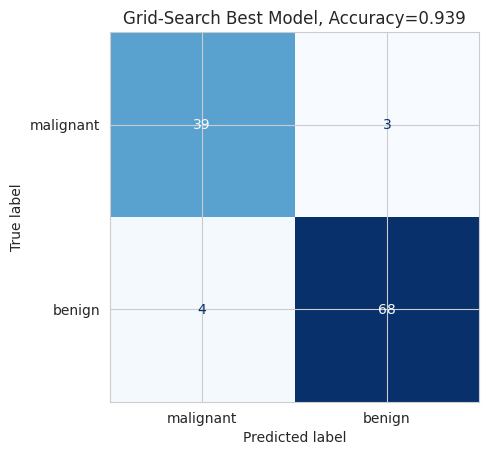

array([[39,  3],
       [ 4, 68]])

In [32]:
best_model = grid_search.best_estimator_

grid_test_pred = best_model.predict(X_test)
grid_test_accuracy = accuracy_score(y_test, grid_test_pred)

baseline_pred = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Grid-search test accuracy:", grid_test_accuracy)
print("Baseline test accuracy:", baseline_accuracy)
print("Manual best test accuracy:", best_acc)

plot_confusion(
    best_model,
    X_test,
    y_test,
    f"Grid-Search Best Model, Accuracy={grid_test_accuracy:.3f}"
)

**TODO (reflection, no code):** Did GridSearchCV beat your manual exploration from
Sections 4-7? If not, why might that be, given cross-validation vs a single
train/test split?

*Your answer:* — *Grid Search selected Gini with max_depth=4 based on the highest average 5-fold cross-validation accuracy of 93.85%, while the manual single train-test split selected depth 3. In this case, both models achieved the same test accuracy of 93.86%, showing that a higher score on one test set does not necessarily mean a model will generalize better. Cross-validation is more reliable for model selection because it evaluates each configuration across multiple validation folds instead of relying on one split.*

---
## 10. Bonus — Feature Importance & Tree Visualization

Top 10 important features:
                 Feature  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161
7    mean concave points    0.013327
13            area error    0.012704
1           mean texture    0.011846
28        worst symmetry    0.011282
3              mean area    0.000000


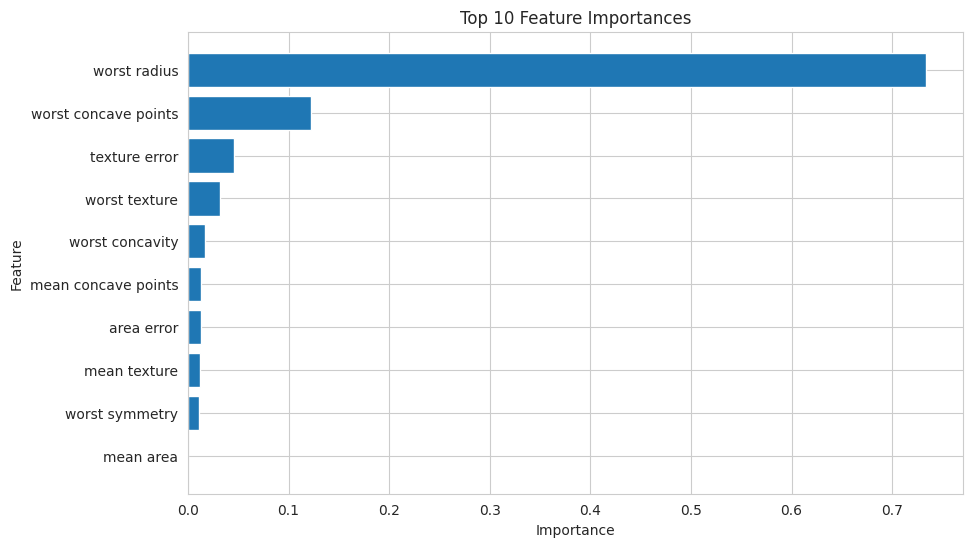

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 important features:")
print(importance.head(10))

plt.figure(figsize=(10, 6))

plt.barh(
    importance.head(10)["Feature"][::-1],
    importance.head(10)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.show()

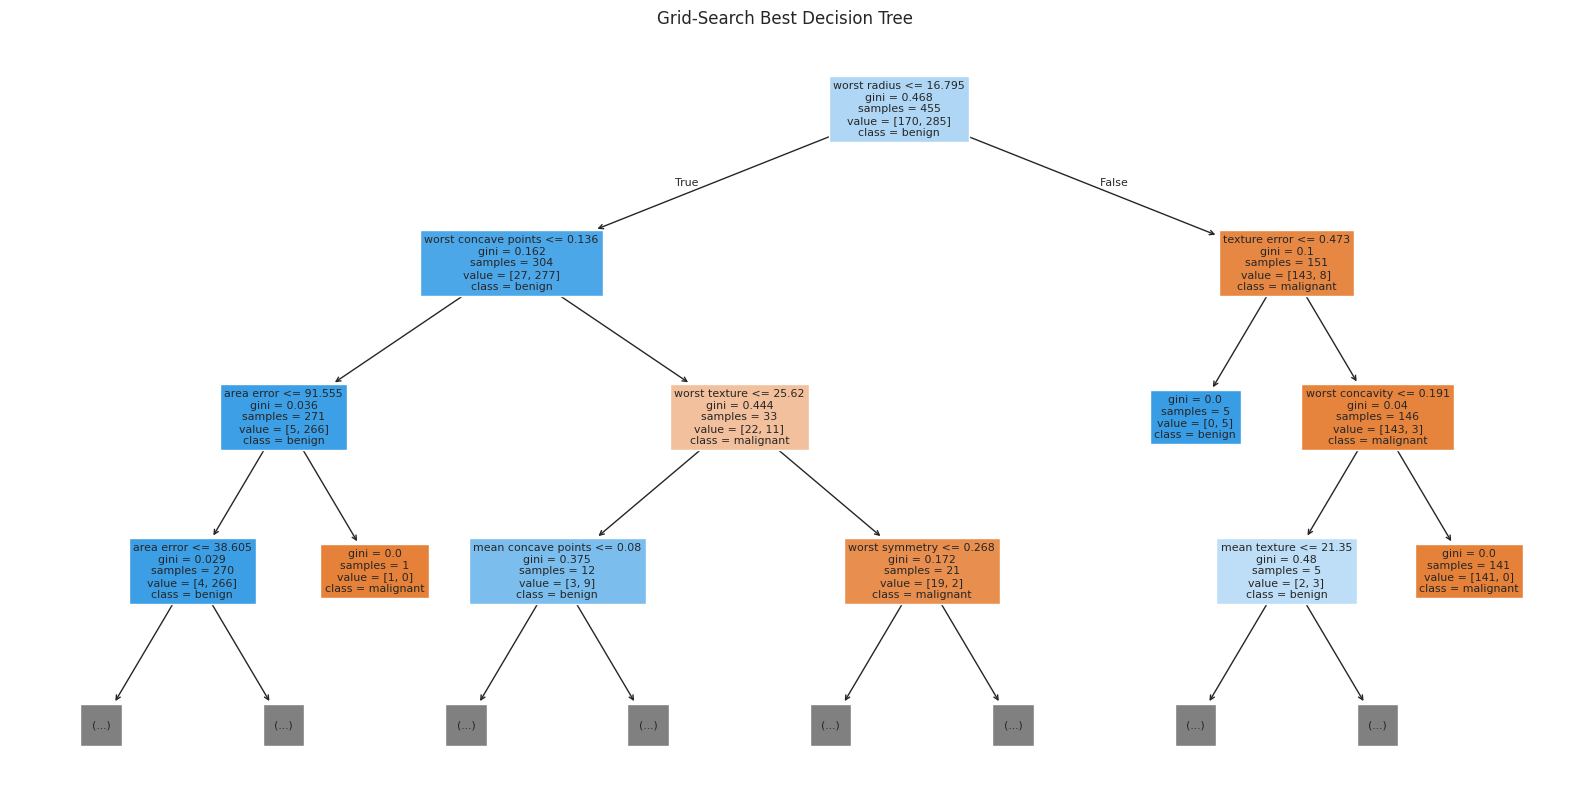

In [34]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3
)

plt.title("Grid-Search Best Decision Tree")
plt.show()

**TODO (reflection, no code):** Does the root-node split use one of the top-3 features
from the importance bar chart above? It should — explain in one sentence why
that's not a coincidence.

*Your answer:* — *Yes, the root-node split uses worst radius, the most important feature in the bar chart, because the root split reduces impurity using all training samples and therefore has a large contribution to the overall feature importance.*

---
## 11. Reflection / Write-up

Answer each of these in 2-4 sentences.

1. **Which hyperparameter had the biggest effect on overfitting — depth, criterion or ccp_alpha?** What made you pick that one?

   *Your answer:* — *I think max_depth had the biggest effect on overfitting because increasing the depth made the training accuracy continue to rise while the test accuracy stopped improving and could decrease. At depth 3, the test accuracy was about 93.86%, while deeper trees did not provide a consistent improvement. The increasing gap between training and test accuracy clearly showed the effect of overfitting.*

2. **Did Gini and Entropy ever meaningfully disagree** — on accuracy, depth, or which
   feature got picked at the root? Or did they behave almost identically throughout?

   *Your answer:* — *Gini and Entropy behaved very similarly in this lab. Both achieved the same test accuracy of 91.23% in the initial comparison, although the resulting full-tree depths were slightly different: 7 for Gini and 6 for Entropy. Therefore, they did not meaningfully disagree in accuracy, even though they could produce slightly different tree structures.*

3. **What would you tell someone who just maximizes test-set accuracy blindly**, without
   looking at confusion matrices or train/test gaps? Use something you saw in this lab
   as evidence.

   *Your answer:* — *I would not choose a model using test accuracy alone because models with similar accuracy can make very different types of errors. In our confusion-matrix comparison, the depth-3 tree achieved 93.9% accuracy with only 3 benign-to-malignant errors, while the overly deep depth-20 tree achieved 91.2% accuracy with 7 benign-to-malignant errors. The train/test accuracy gap should also be checked because a complex tree can fit the training data very well while generalizing worse.*

4. **You controlled tree complexity three different ways in this lab** — `max_depth`
   (Section 5), `ccp_alpha` (Section 7), and `GridSearchCV`'s cross-validated search
   (Section 9).

   a) What's the key difference between how `max_depth` and `ccp_alpha` arrive at
      a simpler tree?

   b) Suppose your manual best from Section 6 scores higher on the test set than
      GridSearchCV's winner. Does that mean the manual pick is a genuinely better
      model? What does this tell you about comparing models this way?

   *Your answer:* — *max_depth creates a simpler tree by stopping its growth early, so the tree is never allowed to become deeper than the specified limit. In contrast, ccp_alpha first allows the tree to grow and then prunes branches afterward, with larger alpha values producing more aggressive pruning. If the manual model gets a higher score on one test set than GridSearchCV's winner, that does not prove it is genuinely better because the manual choice was based on that single test split, whereas GridSearchCV used 5-fold cross-validation. This shows that a single test-set score can be affected by chance, so cross-validation gives a more reliable basis for model selection.*